<center><table>
    <tr>
        <th><img src="./figure/INL1.png" align="middle" height="80"/></th>
        <th><img src="./figure/MIT1.png" align="middle" height="80"/></th>
        <th><img src="./figure/ANL.png" align="middle" height="80"/></th>
    </tr>
</table></center>

# <center>Cost Reduction Framework Sensitivity Analysis</center>

This notebook demonstrates lightweight one-at-a-time sensitivity analysis using the new `src/crf` API.

## 1. Imports and Base Inputs

In [1]:
from pathlib import Path
import os
import sys
import tempfile
import warnings

os.environ.setdefault("MPLCONFIGDIR", tempfile.gettempdir())

import matplotlib.pyplot as plt
import pandas as pd

warnings.simplefilter(action="ignore", category=FutureWarning)
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

cwd = Path.cwd().resolve()
repo_root = next(path for path in [cwd, *cwd.parents] if (path / "src" / "crf").exists())
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

from crf.model.schedule import build_schedule_timeline

from crf import (
    levers_to_dataframe,
    occ_reduction_from_foak_to_noak,
    print_scenario_result,
    results_to_dataframe,
    run_one_scenario,
    save_dashboard,
    waterfall_to_dataframe,
)

output_dir = repo_root / "tutorial"
output_dir.mkdir(exist_ok=True)
print(f"Using ACCERT repository: {repo_root}")

import numpy as np

def show_image(path, figsize=(12, 8)):
    image = plt.imread(path)
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(image)
    ax.axis("off")
    return fig


Using ACCERT repository: /Users/jia.zhou/projects/ACCERT


In [2]:
def base_config(reactor_type):
    startup = 28 if reactor_type == "AP1000" else 16
    return {
        "reactor_type": reactor_type,
        "f_22": 250_000_000,
        "f_2321": 150_000_000,
        "land_cost_per_acre_0": 22_000,
        "startup_0": startup,
        "staggering_ratio": 0.75,
    }


def base_levers(reactor_type):
    common = {
        "num_orders": 10 if reactor_type == "AP1000" else 13,
        "num_NOAK": 8,
        "itc_percent": 0,
        "n_itc": 0,
        "interest_percent": 6,
        "design_completion_percent": 70 if reactor_type == "AP1000" else 80,
        "design_maturity": 1,
        "proc_exp": 0.5,
        "N_proc": 3,
        "ce_exp": 0.5 if reactor_type == "AP1000" else 1.0,
        "N_cons": 5,
        "ae_exp": 0.5,
        "N_AE": 4,
        "standardization_percent": 80,
        "modularity_code": 1,
        "bop_grade_code": 1,
        "rb_grade_code": 0,
    }
    if reactor_type == "AP1000":
        common.update({"modularity_code": 0, "bop_grade_code": 0, "rb_grade_code": 0})
    return common

## Individual Plot Helpers

These helper functions show each dashboard panel as a larger standalone figure for easier notebook inspection.

In [3]:
def _style_ax(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, alpha=0.25)


def plot_capital_cost_panel(result, figsize=(10, 5)):
    df = results_to_dataframe(result)
    x = df["Plant number"]
    fig, ax = plt.subplots(figsize=figsize)
    ax.bar(x - 0.18, df["TCI"], width=0.36, label="10-60 - Total Capital Investment (TCI)", color="tab:green")
    ax.bar(x + 0.18, df["OCC"], width=0.36, label="10-50 - Overnight Capital Cost (OCC)", color="tab:blue")
    if df["Net OCC"].notna().any():
        ax.plot(x, df["Net OCC"], marker="o", linestyle="--", linewidth=1.2, label="Net OCC after ITC")
    if df["NCI"].notna().any():
        ax.plot(x, df["NCI"], marker="o", linestyle="--", linewidth=1.2, label="Net Capital Investment")
    ax.set_title("Capital Cost: OCC and TCI")
    ax.set_xlabel("Plant number")
    ax.set_ylabel("$/kWe")
    ax.legend(fontsize=9)
    _style_ax(ax)
    return fig


def plot_duration_panel(result, figsize=(10, 5)):
    df = results_to_dataframe(result)
    x = df["Plant number"]
    fig, ax = plt.subplots(figsize=figsize)
    ax.bar(x, df["Construction duration"], label="Construction", color="#ff8c2a")
    ax.bar(x, df["Startup duration"], bottom=df["Construction duration"], label="Startup", color="#8b63a9")
    ax.set_title("Total Construction Duration")
    ax.set_xlabel("Plant number")
    ax.set_ylabel("Months")
    ax.legend(fontsize=9)
    _style_ax(ax)
    return fig


def plot_tci_breakdown_panel(result, figsize=(10, 5)):
    df = results_to_dataframe(result)
    x = df["Plant number"]
    columns = [
        ("Preconstruction costs", "10 - Preconstruction", "#4c78a8"),
        ("Direct costs", "20 - Direct", "#72b7b2"),
        ("Indirect costs", "30 - Indirect", "#54a24b"),
        ("Supplementary costs", "50 - Supplementary", "#b279a2"),
        ("Financing costs", "60 - Financing", "#ff9da6"),
    ]
    fig, ax = plt.subplots(figsize=figsize)
    bottom = np.zeros(len(df))
    for column, label, color in columns:
        values = df[column].fillna(0).astype(float).to_numpy()
        ax.bar(x, values, bottom=bottom, label=label, color=color)
        bottom += values
    ax.set_title("10-60 - TCI Breakdown")
    ax.set_xlabel("Plant number")
    ax.set_ylabel("$/kWe")
    ax.legend(fontsize=9)
    _style_ax(ax)
    return fig


def plot_timeline_panel(result, figsize=(11, 5)):
    df = results_to_dataframe(result)
    plants = df["Plant number"].astype(int).to_numpy()
    durations = df["Construction duration"].astype(float).to_numpy()
    startup = df["Startup duration"].fillna(0).astype(float).to_numpy()
    timeline = build_schedule_timeline(
        {"staggering_ratio": result.get("staggering_ratio", 0.75), "reactor_type": result.get("reactor_type", "")},
        plants,
        durations,
        startup,
    )
    start_years = timeline["construction_start_month"] / 12
    duration_years = timeline["construction_duration_months"] / 12
    startup_years = timeline["startup_duration_months"] / 12
    fig, ax = plt.subplots(figsize=figsize)
    ax.barh(plants, duration_years, left=start_years, height=0.64, color="#ff8c2a", edgecolor="black", label="Construction")
    ax.barh(plants, startup_years, left=start_years + duration_years, height=0.64, color="#8b63a9", edgecolor="black", label="Startup")
    ax.set_title("Sequential Construction Timeline")
    ax.set_xlabel("Time (Years)")
    ax.set_ylabel("Reactor Number")
    ax.set_yticks(plants)
    ax.set_ylim(plants.max() + 0.7, plants.min() - 0.7)
    ax.set_xlim(0, float(np.nanmax(start_years + duration_years + startup_years)) * 1.05)
    ax.grid(True, axis="x", alpha=0.35)
    ax.legend(fontsize=9)
    return fig


def plot_occ_components_panel(result, figsize=(10, 5)):
    df = results_to_dataframe(result)
    x = df["Plant number"]
    columns = [
        ("Direct costs: equipment", "20 - Direct: Equipment", "#72b7b2"),
        ("Direct costs: material", "20 - Direct: Material", "#f58518"),
        ("Direct costs: labor", "20 - Direct: Labor", "#e45756"),
        ("Indirect costs", "30 - Indirect", "#54a24b"),
        ("Supplementary costs", "50 - Supplementary", "#b279a2"),
    ]
    fig, ax = plt.subplots(figsize=figsize)
    bottom = np.zeros(len(df))
    for column, label, color in columns:
        values = df[column].fillna(0).astype(float).to_numpy()
        ax.bar(x, values, bottom=bottom, label=label, color=color)
        bottom += values
    ax.set_title("10-50 - OCC Components")
    ax.set_xlabel("Plant number")
    ax.set_ylabel("$/kWe")
    ax.legend(fontsize=9)
    _style_ax(ax)
    return fig


def plot_waterfall_panel(result, figsize=(11, 5)):
    waterfall = waterfall_to_dataframe(result)
    foak_occ = float(waterfall.iloc[0]["cumulative_occ"])
    x = np.arange(len(waterfall))
    labels = ["\n".join(str(label).replace("\n", " ").split()) for label in waterfall["label"]]
    labels = ["\n".join(label.split()[:3]) if len(label) > 18 else label for label in labels]
    bottoms, heights, colors, pct_labels = [], [], [], []
    noak_reduction = occ_reduction_from_foak_to_noak(result)
    for _, row in waterfall.iterrows():
        if row["kind"] == "total":
            total = float(row["cumulative_occ"])
            bottoms.append(0)
            heights.append(total)
            colors.append("#4c78a8")
            pct_labels.append("100%" if row.name == 0 else f"{noak_reduction:.1f}% lower")
        else:
            current = float(row["cumulative_occ"])
            change = float(row["absolute_change"])
            previous = current - change
            bottoms.append(previous if change >= 0 else current)
            heights.append(abs(change))
            colors.append("#f58518" if change >= 0 else "#54a24b")
            pct_labels.append(f"{change / foak_occ * 100:+.1f}%")
    fig, ax = plt.subplots(figsize=figsize)
    ax.bar(x, heights, bottom=bottoms, color=colors, width=0.72)
    for idx in range(len(waterfall) - 1):
        y = float(waterfall.iloc[idx]["cumulative_occ"])
        ax.plot([idx + 0.36, idx + 1 - 0.36], [y, y], color="#777777", linewidth=0.8)
    max_y = max(bottom + height for bottom, height in zip(bottoms, heights))
    for idx, (bottom, height, label) in enumerate(zip(bottoms, heights, pct_labels)):
        if height > 0:
            ax.text(idx, bottom + height / 2, label, ha="center", va="center", fontsize=8, fontweight="bold", color="white")
    ax.set_title("% OCC Reduction from FOAK to NOAK")
    ax.set_ylabel("OCC ($/kWe)")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylim(0, max_y * 1.12)
    _style_ax(ax)
    return fig

## 2. Helper Function

In [4]:
def evaluate_case(name, reactor_type="AP1000", config_updates=None, lever_updates=None):
    config = base_config(reactor_type)
    levers = base_levers(reactor_type)
    if config_updates:
        config.update(config_updates)
    if lever_updates:
        levers.update(lever_updates)
    result = run_one_scenario(config, levers)
    return {
        "Case": name,
        "Reactor": reactor_type,
        "Firm orders": result["Num_orders"],
        "Average OCC ($/kWe)": result["avg_OCC"],
        "Average TCI ($/kWe)": result["avg_TCI"],
        "NOAK OCC reduction (%)": occ_reduction_from_foak_to_noak(result),
        "Cumulative timeline (months)": result["cons_duration_cumulative_wz_startup"],
    }

## 3. Order Book Sensitivity

In [5]:
order_rows = [evaluate_case(f"{n} orders", lever_updates={"num_orders": n, "num_NOAK": min(n, 5)}) for n in [2, 3, 5, 8]]
orders = pd.DataFrame(order_rows)
orders.round(2)

,Case,Reactor,Firm orders,Average OCC ($/kWe),Average TCI ($/kWe),NOAK OCC reduction (%),Cumulative timeline (months)
0,2 orders,AP1000,2,12183.32,14345.09,43.85,119.00
1,3 orders,AP1000,3,10311.04,11999.97,57.17,119.00
2,5 orders,AP1000,5,8174.44,9378.60,69.78,133.73
3,8 orders,AP1000,8,6759.85,7646.01,69.80,166.94


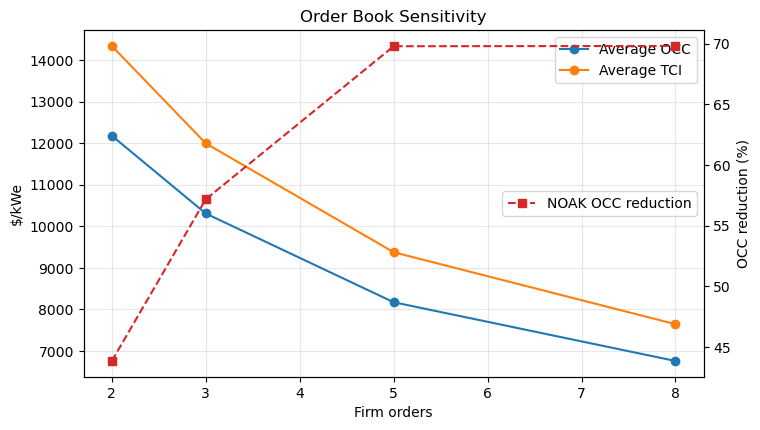

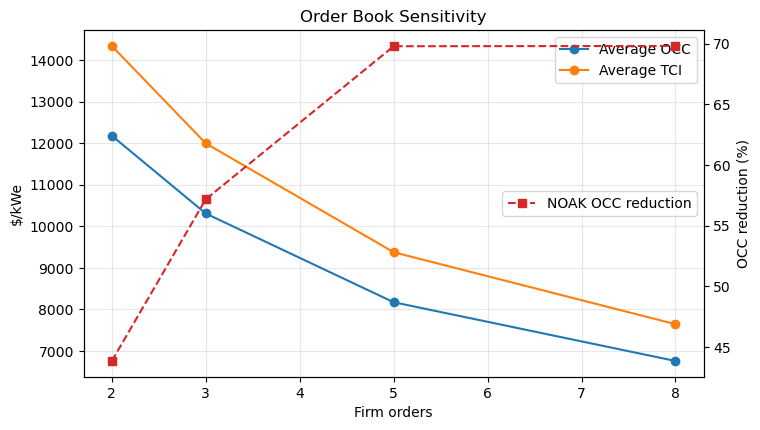

In [6]:
fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax1.plot(orders["Firm orders"], orders["Average OCC ($/kWe)"], marker="o", label="Average OCC")
ax1.plot(orders["Firm orders"], orders["Average TCI ($/kWe)"], marker="o", label="Average TCI")
ax1.set_xlabel("Firm orders")
ax1.set_ylabel("$/kWe")
ax1.grid(True, alpha=0.3)
ax1.legend(loc="upper right")

ax2 = ax1.twinx()
ax2.plot(orders["Firm orders"], orders["NOAK OCC reduction (%)"], color="tab:red", marker="s", linestyle="--", label="NOAK OCC reduction")
ax2.set_ylabel("OCC reduction (%)")
ax2.legend(loc="center right")
plt.title("Order Book Sensitivity")
fig

## 4. One-at-a-Time Lever Sensitivity

Each case changes one lever from the AP1000 baseline.

In [7]:
baseline = evaluate_case("Baseline")
lever_cases = [
    evaluate_case("Lower interest", lever_updates={"interest_percent": 4}),
    evaluate_case("Higher interest", lever_updates={"interest_percent": 8}),
    evaluate_case("More standardization", lever_updates={"standardization_percent": 100}),
    evaluate_case("Less standardization", lever_updates={"standardization_percent": 40}),
    evaluate_case("More complete design", lever_updates={"design_completion_percent": 90}),
    evaluate_case("Lower construction proficiency", lever_updates={"ce_exp": 0.25}),
]

lever_df = pd.DataFrame([baseline, *lever_cases])
lever_df["Delta avg OCC ($/kWe)"] = lever_df["Average OCC ($/kWe)"] - baseline["Average OCC ($/kWe)"]
lever_df.round(2)

,Case,Reactor,Firm orders,Average OCC ($/kWe),Average TCI ($/kWe),NOAK OCC reduction (%),Cumulative timeline (months),Delta avg OCC ($/kWe)
0,Baseline,AP1000,10,6237.29,7005.07,72.58,190.56,0.00
1,Lower interest,AP1000,10,6237.29,6739.39,72.58,190.56,0.00
2,Higher interest,AP1000,10,6237.29,7281.22,72.58,190.56,0.00
3,More standardization,AP1000,10,5861.16,6563.35,75.21,162.64,-376.13
4,Less standardization,AP1000,10,7227.43,8152.46,65.07,238.96,990.14
5,More complete design,AP1000,10,6026.80,6750.03,68.31,189.80,-210.49
6,Lower construction proficiency,AP1000,10,6484.72,7292.09,74.36,190.96,247.43


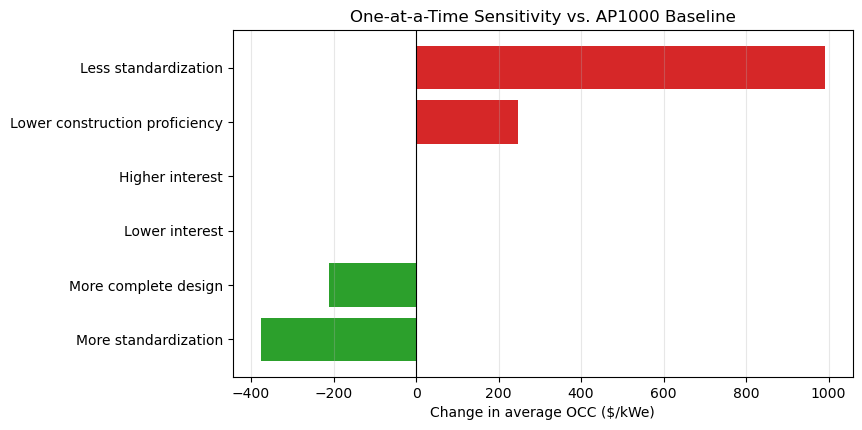

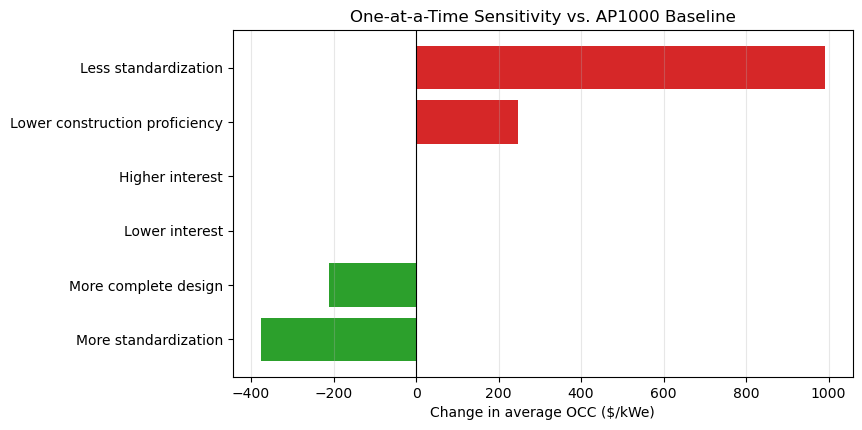

In [8]:
plot_df = lever_df[lever_df["Case"] != "Baseline"].sort_values("Delta avg OCC ($/kWe)")
colors = ["tab:green" if value < 0 else "tab:red" for value in plot_df["Delta avg OCC ($/kWe)"]]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(plot_df["Case"], plot_df["Delta avg OCC ($/kWe)"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Change in average OCC ($/kWe)")
ax.set_title("One-at-a-Time Sensitivity vs. AP1000 Baseline")
ax.grid(True, axis="x", alpha=0.3)
fig

## 5. Save a Dashboard for a Sensitivity Case

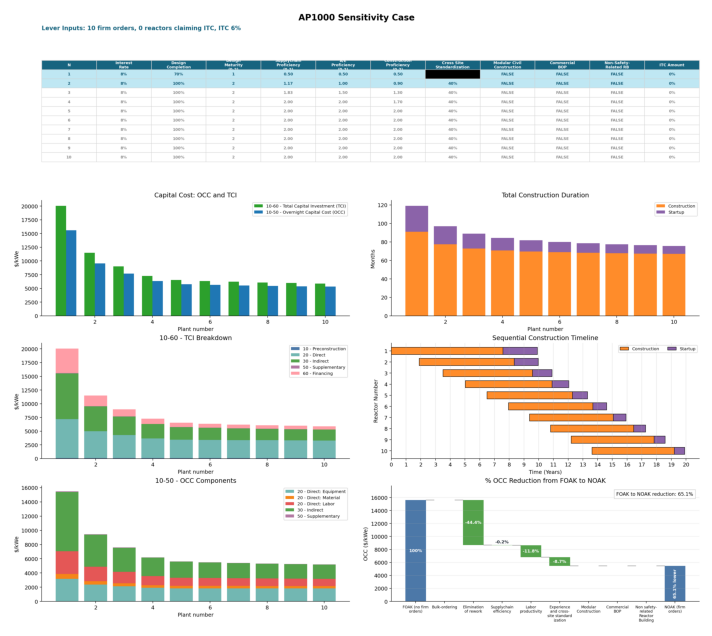

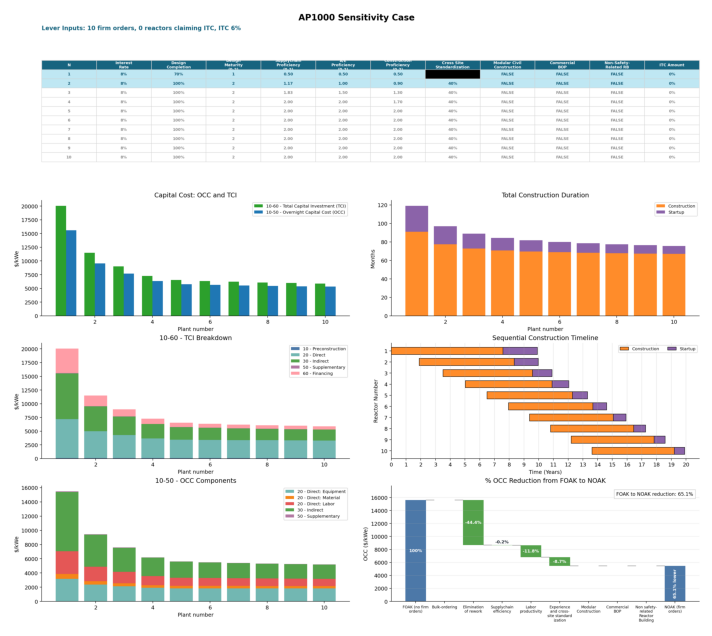

In [9]:
case_config = base_config("AP1000")
case_levers = base_levers("AP1000")
case_levers.update({"interest_percent": 8, "standardization_percent": 40})
case_result = run_one_scenario(case_config, case_levers)

sensitivity_dashboard = output_dir / "crf_sensitivity_case_dashboard.png"
save_dashboard(case_result, sensitivity_dashboard, title="AP1000 Sensitivity Case", show_levers=True)
show_image(sensitivity_dashboard)

## 6. Inspect Sensitivity Case Panels

These cells show selected dashboard panels from the sensitivity case as larger standalone figures.

### Sensitivity Case Capital Cost

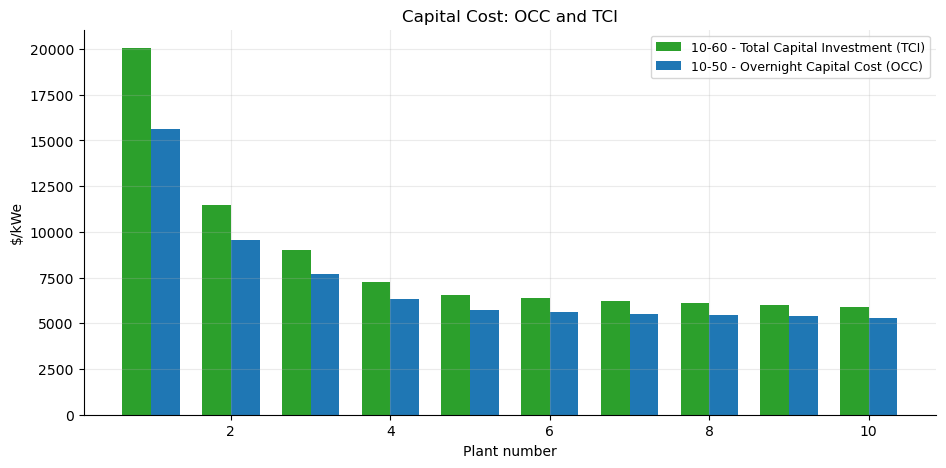

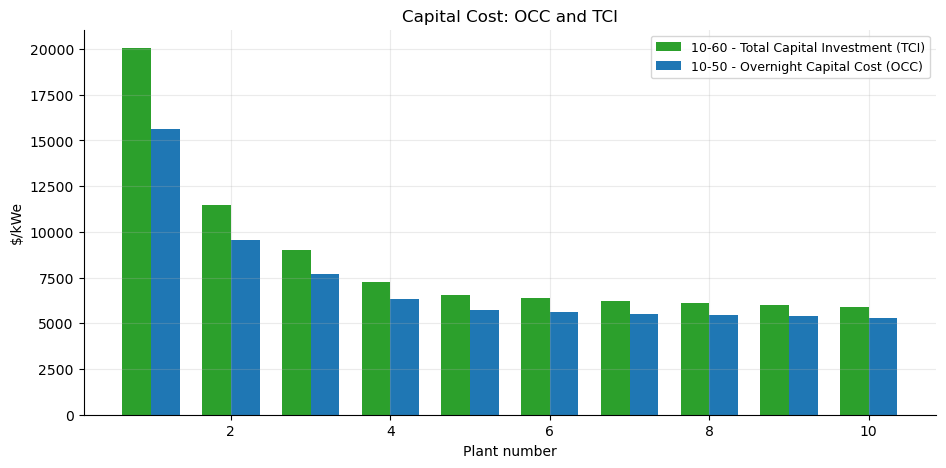

In [10]:
plot_capital_cost_panel(case_result, figsize=(11, 5))

### Sensitivity Case Timeline

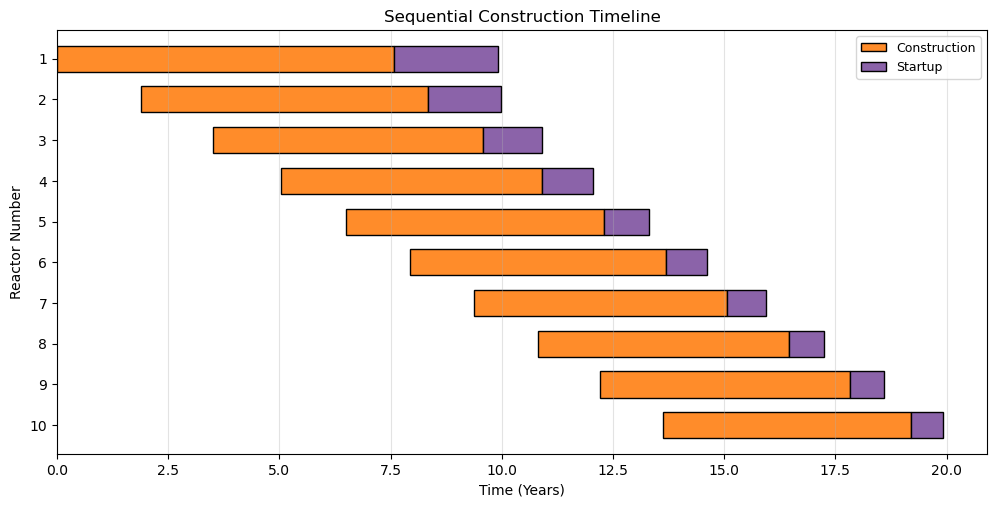

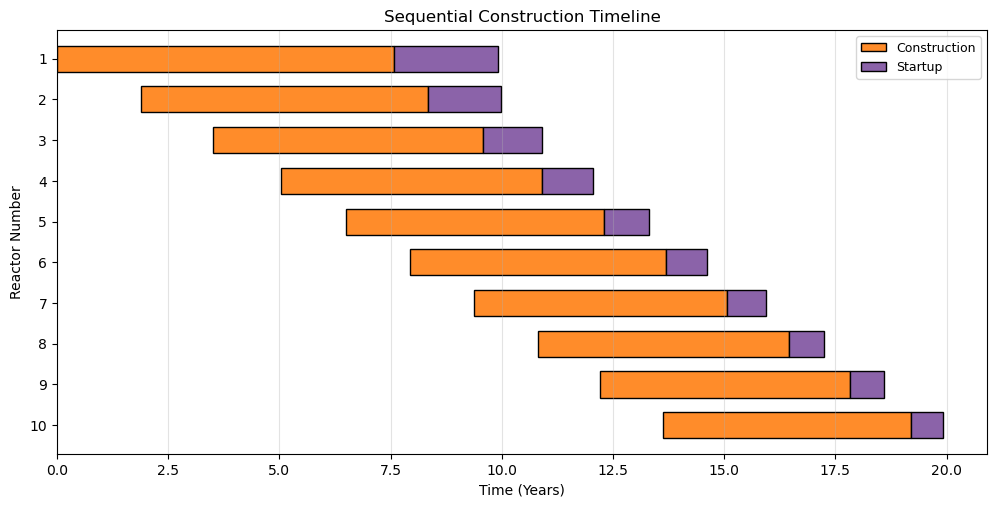

In [11]:
plot_timeline_panel(case_result, figsize=(12, 5.5))

### Sensitivity Case Waterfall

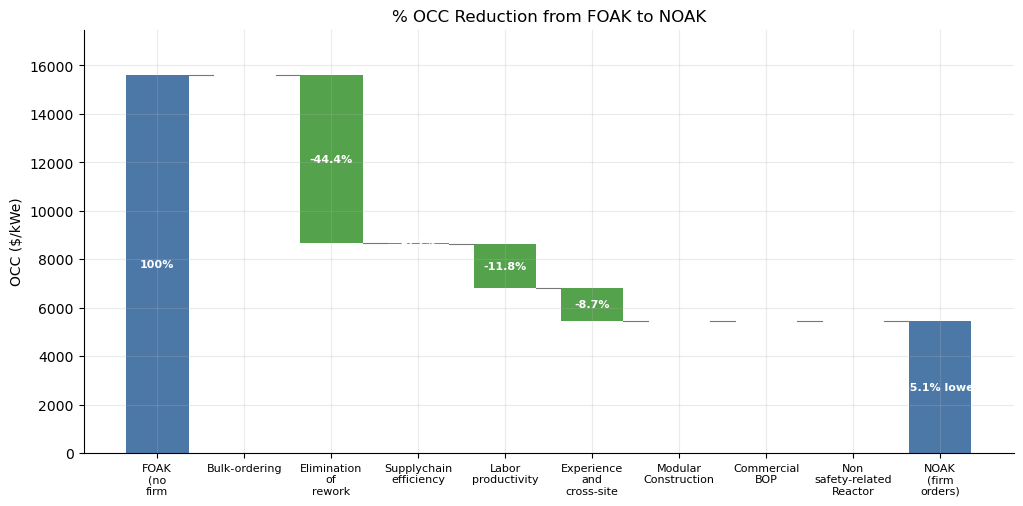

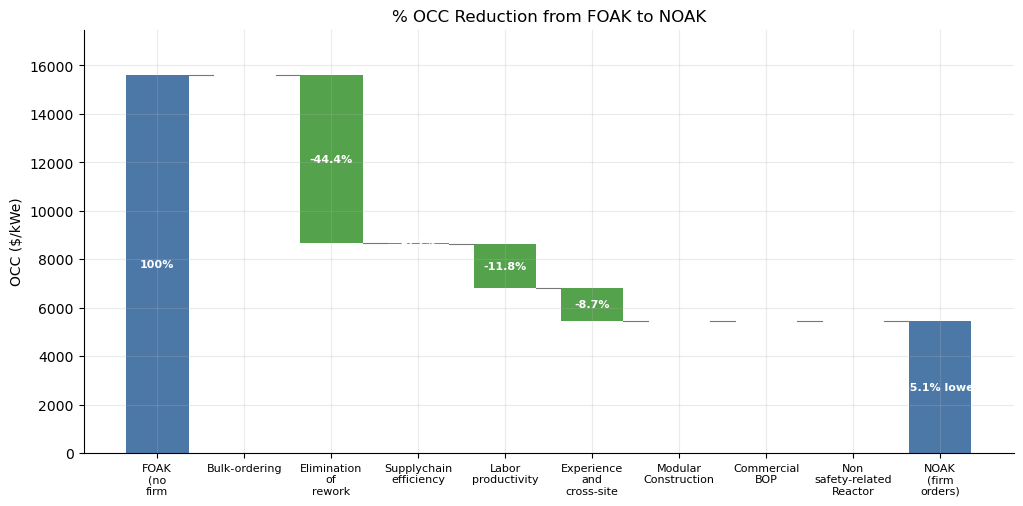

In [12]:
plot_waterfall_panel(case_result, figsize=(12, 5.5))